In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y, genlaguerre
import math

7
The distance from the nucleus with the highest probability of finding an electron is 1.0552763819095476


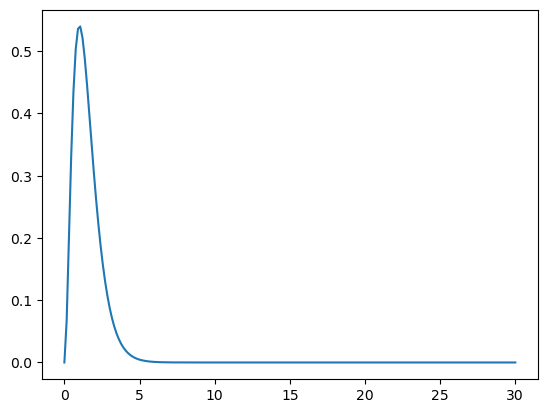

In [90]:
#Plotting a graph of radial distribution function against the distance r from the nucleus 

#Maxima of RDF: highest probability of finding an electron at that distance r -> optimal r value for subsequent plots 

#State values of n and l
n_value = 1
l_value = 0


a = 1  # Bohr radius
r = np.linspace(0, 30, 200)

#Defining a function that computes the radial part
def radial(n, l, r):
    rho = 2 * r / (n * a)
    norm = np.sqrt((2 / (n * a))**3 * math.factorial(n - l - 1) / (2 * n * math.factorial(n + l)))
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)(rho)
    R = norm * np.exp(-rho / 2) * rho**l * laguerre
    return R

radial_part = radial(1, 0, r)
rdf = (r**2) * (np.abs(radial_part)**2)

#Finding the index of the rdf maxima, and accessing the r array to get the r value 
max_rdf_index = np.argmax(rdf)
print(max_rdf_index)
print(f"The distance from the nucleus with the highest probability of finding an electron is {r[max_rdf_index]}")

plt.plot(r, rdf)
plt.show()


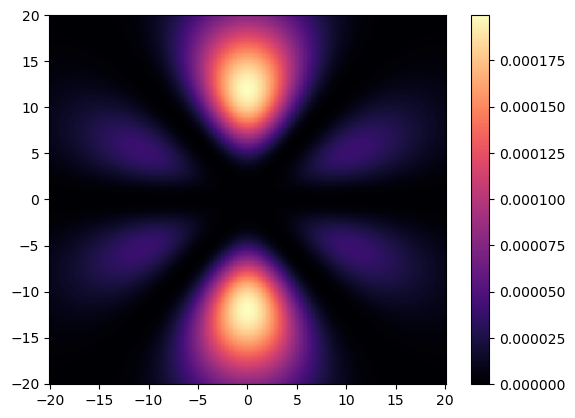

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y, genlaguerre
import math

a = 1  # Bohr radius


x = np.linspace(-20,20,300)

z = np.linspace(-20,20,300)

X,Z = np.meshgrid(x,z)
Y = 0


r = np.sqrt(X**2+Y**2+Z**2)
theta = np.arccos(Z/r)
phi = np.arctan2(Y,X)

def radial(n, l, r):
    rho = 2 * r / (n * a)
    norm = np.sqrt((2 / (n * a))**3 * math.factorial(n - l - 1) / (2 * n * math.factorial(n + l)))
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)(rho)
    R = norm * np.exp(-rho / 2) * rho**l * laguerre
    return R

def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag

radial_part = radial(4, 3, r)
angular_part = angular(3,0)
wavefunction = np.abs(radial_part * angular_part)
e_density = np.abs(wavefunction)**2


plt.pcolormesh(X,Z,e_density, cmap='magma')
plt.colorbar()
plt.show()










ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

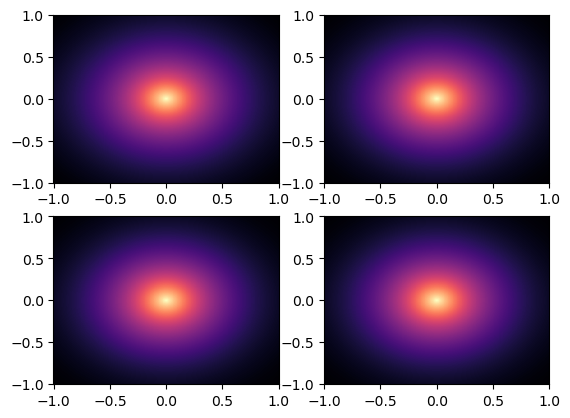

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y, genlaguerre
import math

a = 1  # Bohr radius


x = np.linspace(-1,1,500)
z = np.linspace(-1,1,500)

X,Z = np.meshgrid(x,z)
Y = 0


r = np.sqrt(X**2+Y**2+Z**2)
theta = np.arccos(Z/r)
phi = np.arctan2(Y,X)

def radial(n, l, r):
    rho = 2 * r / (n * a)
    norm = np.sqrt((2 / (n * a))**3 * math.factorial(n - l - 1) / (2 * n * math.factorial(n + l)))
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)(rho)
    R = norm * np.exp(-rho / 2) * rho**l * laguerre
    return R

def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag


fig, ax = plt.subplots(ncols=2,nrows=2)

e_density_list = []
n_list = [1,2,3,4]
for i in n_list:
    radial_part = radial(i,0,r)
    angular_part = angular(0,0)
    wavefunction = np.abs(radial_part * angular_part)
    e_density = np.abs(wavefunction)**2
    e_density_list.append(e_density)


ax[0,0].pcolormesh(X,Z,e_density_list[0], cmap='magma')
ax[0,1].pcolormesh(X,Z,e_density_list[1], cmap='magma')
ax[1,0].pcolormesh(X,Z,e_density_list[2], cmap='magma')
ax[1,1].pcolormesh(X,Z,e_density_list[3], cmap='magma')
fig.colorbar(e_density_list)


plt.show()










In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y, genlaguerre
import math
a = 1  # Bohr radius

r = np.random.rand(300)

theta, phi = np.meshgrid(np.linspace(0, np.pi, 200), np.linspace(0, 2 * np.pi, 200))

def radial(n, l, r):
    rho = 2 * r / (n * a)
    norm = np.sqrt((2 / (n * a))**3 * math.factorial(n - l - 1) / (2 * n * math.factorial(n + l)))
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)(rho)
    R = norm * np.exp(-rho / 2) * rho**l * laguerre
    return R

def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag

radial_part = radial(3, 1, r)
angular_part = angular(1,0)
wavefunction = np.abs(radial_part * angular_part)
e_density = np.abs(wavefunction)**2

x = radial_part * np.sin(theta) * np.cos(phi)
y = radial_part * np.sin(theta) * np.sin(phi)
z = radial_part * np.cos(theta)

X, Y, Z = x * np.abs(wavefunction), y * np.abs(wavefunction), z * np.abs(wavefunction)


# plt.imshow(e_density, extent=[-20, 20, -20, 20], cmap = 'magma')
plt.pcolormesh(X,Z, e_density, cmap = 'magma')
plt.colorbar()
plt.show()





ValueError: operands could not be broadcast together with shapes (300,) (200,200) 

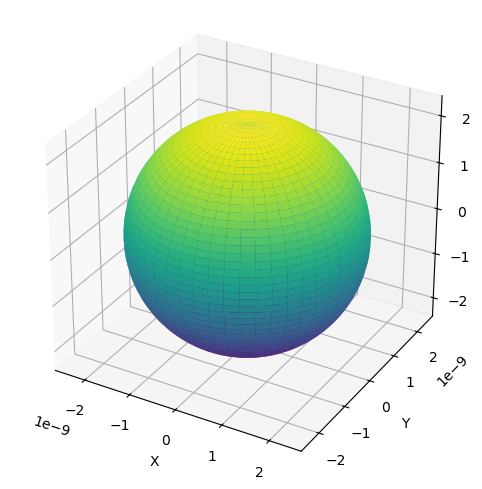

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y, genlaguerre
import math
a = 1  # Bohr radius

r = 10
theta, phi = np.meshgrid(np.linspace(0, np.pi, 200), np.linspace(0, 2 * np.pi, 200))

def radial(n, l, r):
    rho = 2 * r / (n * a)
    norm = np.sqrt((2 / (n * a))**3 * math.factorial(n - l - 1) / (2 * n * math.factorial(n + l)))
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)(rho)
    R = norm * np.exp(-rho / 2) * rho**l * laguerre
    return R

def angular(l,m):
    Y = sph_harm_y(l, m, theta, phi)
    if m == 0:
        return Y
    elif m > 0:
        Y_real = Y.real
        return Y_real
    else:
        Y_imag = Y.imag
        return Y_imag

radial_part = radial(1, 0, r)
angular_part = angular(0,0)
wavefunction = np.abs(radial_part * angular_part)
e_density = np.abs(wavefunction)**2

x = radial_part * np.sin(theta) * np.cos(phi)
y = radial_part * np.sin(theta) * np.sin(phi)
z = radial_part * np.cos(theta)

X, Y, Z = x * wavefunction, y * wavefunction, z * wavefunction

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1, projection = '3d')
ax.plot_surface(X,Y,Z,cmap='viridis')
ax.set_aspect('equal')
ax.set(xlabel='X', ylabel='Y', zlabel='Z')

plt.show()


C:\Users\natha\AppData\Local\Temp\ipykernel_17720\267367659.py:14: RuntimeWarning: invalid value encountered in divide
  Theta = numpy.arccos(Z/R)
C:\Users\natha\AppData\Local\Temp\ipykernel_17720\267367659.py:18: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  s_harm=sph_harm(m, l, Phi, Theta)


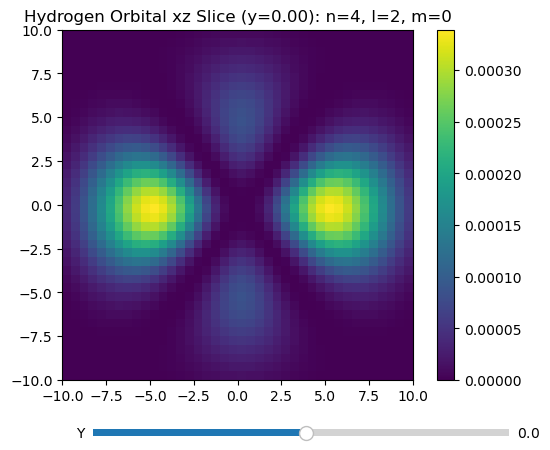

In [ ]:
import numpy
import math
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, RadioButtons
import scipy.special
from scipy.special import sph_harm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import ListedColormap


def hydrogen_wf(n,l,m,X,Y,Z):
    R = numpy.sqrt(X**2+Y**2+Z**2)
    Theta = numpy.arccos(Z/R)
    Phi = numpy.arctan2(Y,X)
    
    rho = 2.*R/n
    s_harm=sph_harm(m, l, Phi, Theta)
    l_poly = scipy.special.genlaguerre(n-l-1,2*l+1)(rho)
    
    prefactor = numpy.sqrt((2./n)**3*math.factorial(n-l-1)/(2.*n*math.factorial(n+l)))
    wf = prefactor*numpy.exp(-rho/2.)*rho**l*s_harm*l_poly
    wf = numpy.nan_to_num(wf)
    return wf
  
dz=0.5
zmin=-10
zmax=10
x = numpy.arange(zmin,zmax,dz)
y = numpy.arange(zmin,zmax,dz)
z = numpy.arange(zmin,zmax,dz)
X,Y,Z = numpy.meshgrid(x,y,z) #X, Y, Z are 3d arrays that tell us the values of x, y, and z at every point in space

#Change these to change which orbital to plot
n=4
l=2
m=0

data = hydrogen_wf(n,l,m,X,Y,Z)
data = abs(data)**2

R = numpy.sqrt(X**2+Y**2+Z**2)

fig, ax = plt.subplots()
plt.subplots_adjust(left=0.15, bottom=0.15)
im = plt.imshow(data[int((0-zmin)/dz),:,:], vmin=0, vmax = numpy.max(data), extent=[zmin,zmax,zmin,zmax])
plt.colorbar()
sli = Slider(plt.axes([0.25, 0.025, 0.65, 0.03]), "Y", z[0], z[len(z)-1], valinit=0)
ax.set_title("Hydrogen Orbital xz Slice (y="+str("%.2f"%sli.val)+"): n="+str(n)+", l="+str(l)+", m="+str(m))

def update(val):
    index = int((sli.val-zmin) / dz)
    im.set_data(data[index,:,:])
    ax.set_title("Hydrogen Orbital xz Slice (y="+str("%.2f"%sli.val)+"): n="+str(n)+", l="+str(l)+", m="+str(m))
       
sli.on_changed(update)
plt.show()

<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
C:\Users\natha\AppData\Local\Temp\ipykernel_34120\1629550441.py:37: SyntaxWarning: invalid escape sequence '\p'
  plt.title("$|\psi_{nlm}|^2$(x=0,y=0,z): n="+str(n)+", l="+str(l)+", m="+str(m))
C:\Users\natha\AppData\Local\Temp\ipykernel_34120\1629550441.py:39: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$|\psi_{nlm}|^2$")
C:\Users\natha\AppData\Local\Temp\ipykernel_34120\1629550441.py:9: RuntimeWarning: invalid value encountered in divide
  Theta = numpy.arccos(Z/R)
C:\Users\natha\AppData\Local\Temp\ipykernel_34120\1629550441.py:13: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  s_harm=sph_harm(m, l, Phi, Theta)


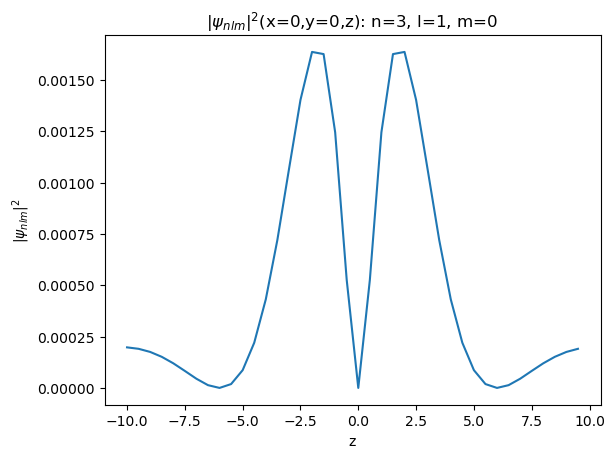

In [45]:
import numpy
import math
import matplotlib.pyplot as plt
import scipy.special
from scipy.special import sph_harm

def hydrogen_wf(n,l,m,X,Y,Z):
    R = numpy.sqrt(X**2+Y**2+Z**2)
    Theta = numpy.arccos(Z/R)
    Phi = numpy.arctan2(Y,X)
    
    rho = 2.*R/n
    s_harm=sph_harm(m, l, Phi, Theta)
    l_poly = scipy.special.genlaguerre(n-l-1,2*l+1)(rho)
    
    prefactor = numpy.sqrt((2./n)**3*math.factorial(n-l-1)/(2.*n*math.factorial(n+l)))
    wf = prefactor*numpy.exp(-rho/2.)*rho**l*s_harm*l_poly
    wf = numpy.nan_to_num(wf)
    return wf
  
dz=0.5
zmin=-10
zmax=10
x = numpy.arange(zmin,zmax,dz)
y = numpy.arange(zmin,zmax,dz)
z = numpy.arange(zmin,zmax,dz)
X,Y,Z = numpy.meshgrid(x,y,z) #X, Y, Z are 3d arrays that tell us the values of x, y, and z at every point in space
n=3
l=1
m=0
data = hydrogen_wf(n,l,m,X,Y,Z)
data = abs(data)**2
R = numpy.sqrt(X**2+Y**2+Z**2)

plt.figure()
plt.plot(z, data[int(len(z)/2),int(len(z)/2),:])
plt.title("$|\psi_{nlm}|^2$(x=0,y=0,z): n="+str(n)+", l="+str(l)+", m="+str(m))
plt.xlabel('z')
plt.ylabel("$|\psi_{nlm}|^2$")
plt.show()